In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.2 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os
from IPython.display import Image
import shutil

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!wget -nc https://github.com/ultralytics/yolov5/releases/download/v1.0/coco128.zip

--2026-03-30 17:42:23--  https://github.com/ultralytics/yolov5/releases/download/v1.0/coco128.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/264818686/854f8531-cc3e-47d1-9f20-5d8fa189e18a?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-30T18%3A26%3A28Z&rscd=attachment%3B+filename%3Dcoco128.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-30T17%3A25%3A52Z&ske=2026-03-30T18%3A26%3A28Z&sks=b&skv=2018-11-09&sig=BsfpIeS6PPr09ZnHMFvqNpdIa490T1kWfQGu9yD6OCA%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NDg5Mjg0MywibmJmIjoxNzc0ODkyNTQzLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud

In [ ]:
!unzip coco128.zip

Archive:  coco128.zip
   creating: coco128/
  inflating: coco128/LICENSE         
   creating: coco128/images/
   creating: coco128/images/train2017/
  inflating: coco128/images/train2017/000000000612.jpg  
  inflating: coco128/images/train2017/000000000404.jpg  
  inflating: coco128/images/train2017/000000000438.jpg  
  inflating: coco128/images/train2017/000000000389.jpg  
  inflating: coco128/images/train2017/000000000564.jpg  
  inflating: coco128/images/train2017/000000000149.jpg  
  inflating: coco128/images/train2017/000000000605.jpg  
  inflating: coco128/images/train2017/000000000349.jpg  
  inflating: coco128/images/train2017/000000000201.jpg  
  inflating: coco128/images/train2017/000000000599.jpg  
  inflating: coco128/images/train2017/000000000572.jpg  
  inflating: coco128/images/train2017/000000000360.jpg  
  inflating: coco128/images/train2017/000000000370.jpg  
  inflating: coco128/images/train2017/000000000562.jpg  
  inflating: coco128/images/train2017/000000000589.j

In [ ]:
yaml_content = """
path: /content/coco128

train: images/train2017
val: images/train2017

names:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: boat
  9: traffic light
"""

with open("/content/coco128/coco128.yaml", "w") as f:
    f.write(yaml_content)

In [ ]:
!ls coco128

coco128.yaml  images  labels  LICENSE  README.txt


In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
results = model.train(
    data="/content/coco128/coco128.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10
)

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/coco128/coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1648.1±607.9 MB/s, size: 53.4 KB)
val: Scanning /content/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 113 corrupt: 100% ━━━━━━━━━━━━ 128/128 15.8Mit/s 0.0s
train: /content/coco128/images/train2017/000000000009.jpg: ignoring corrupt image/label: Label class 50 exceeds dataset class count 10. Possible class labels are 0-9
train: /content/coco128/images/train2017/000000000025.jpg: ignoring corrupt image/label: Label class 23 exceeds dataset class count 10. Possible class labels are 0-9
train: /content/coco128/images/train2017/000000000030.jpg: ignoring corrupt image/label: Label class 75 exceeds dataset class count 10. Possible class labels are 0-9
train: /content/coco128/images/train2017/000000000034.jpg: ignoring corrupt image/label: Label class 22 exceeds datas

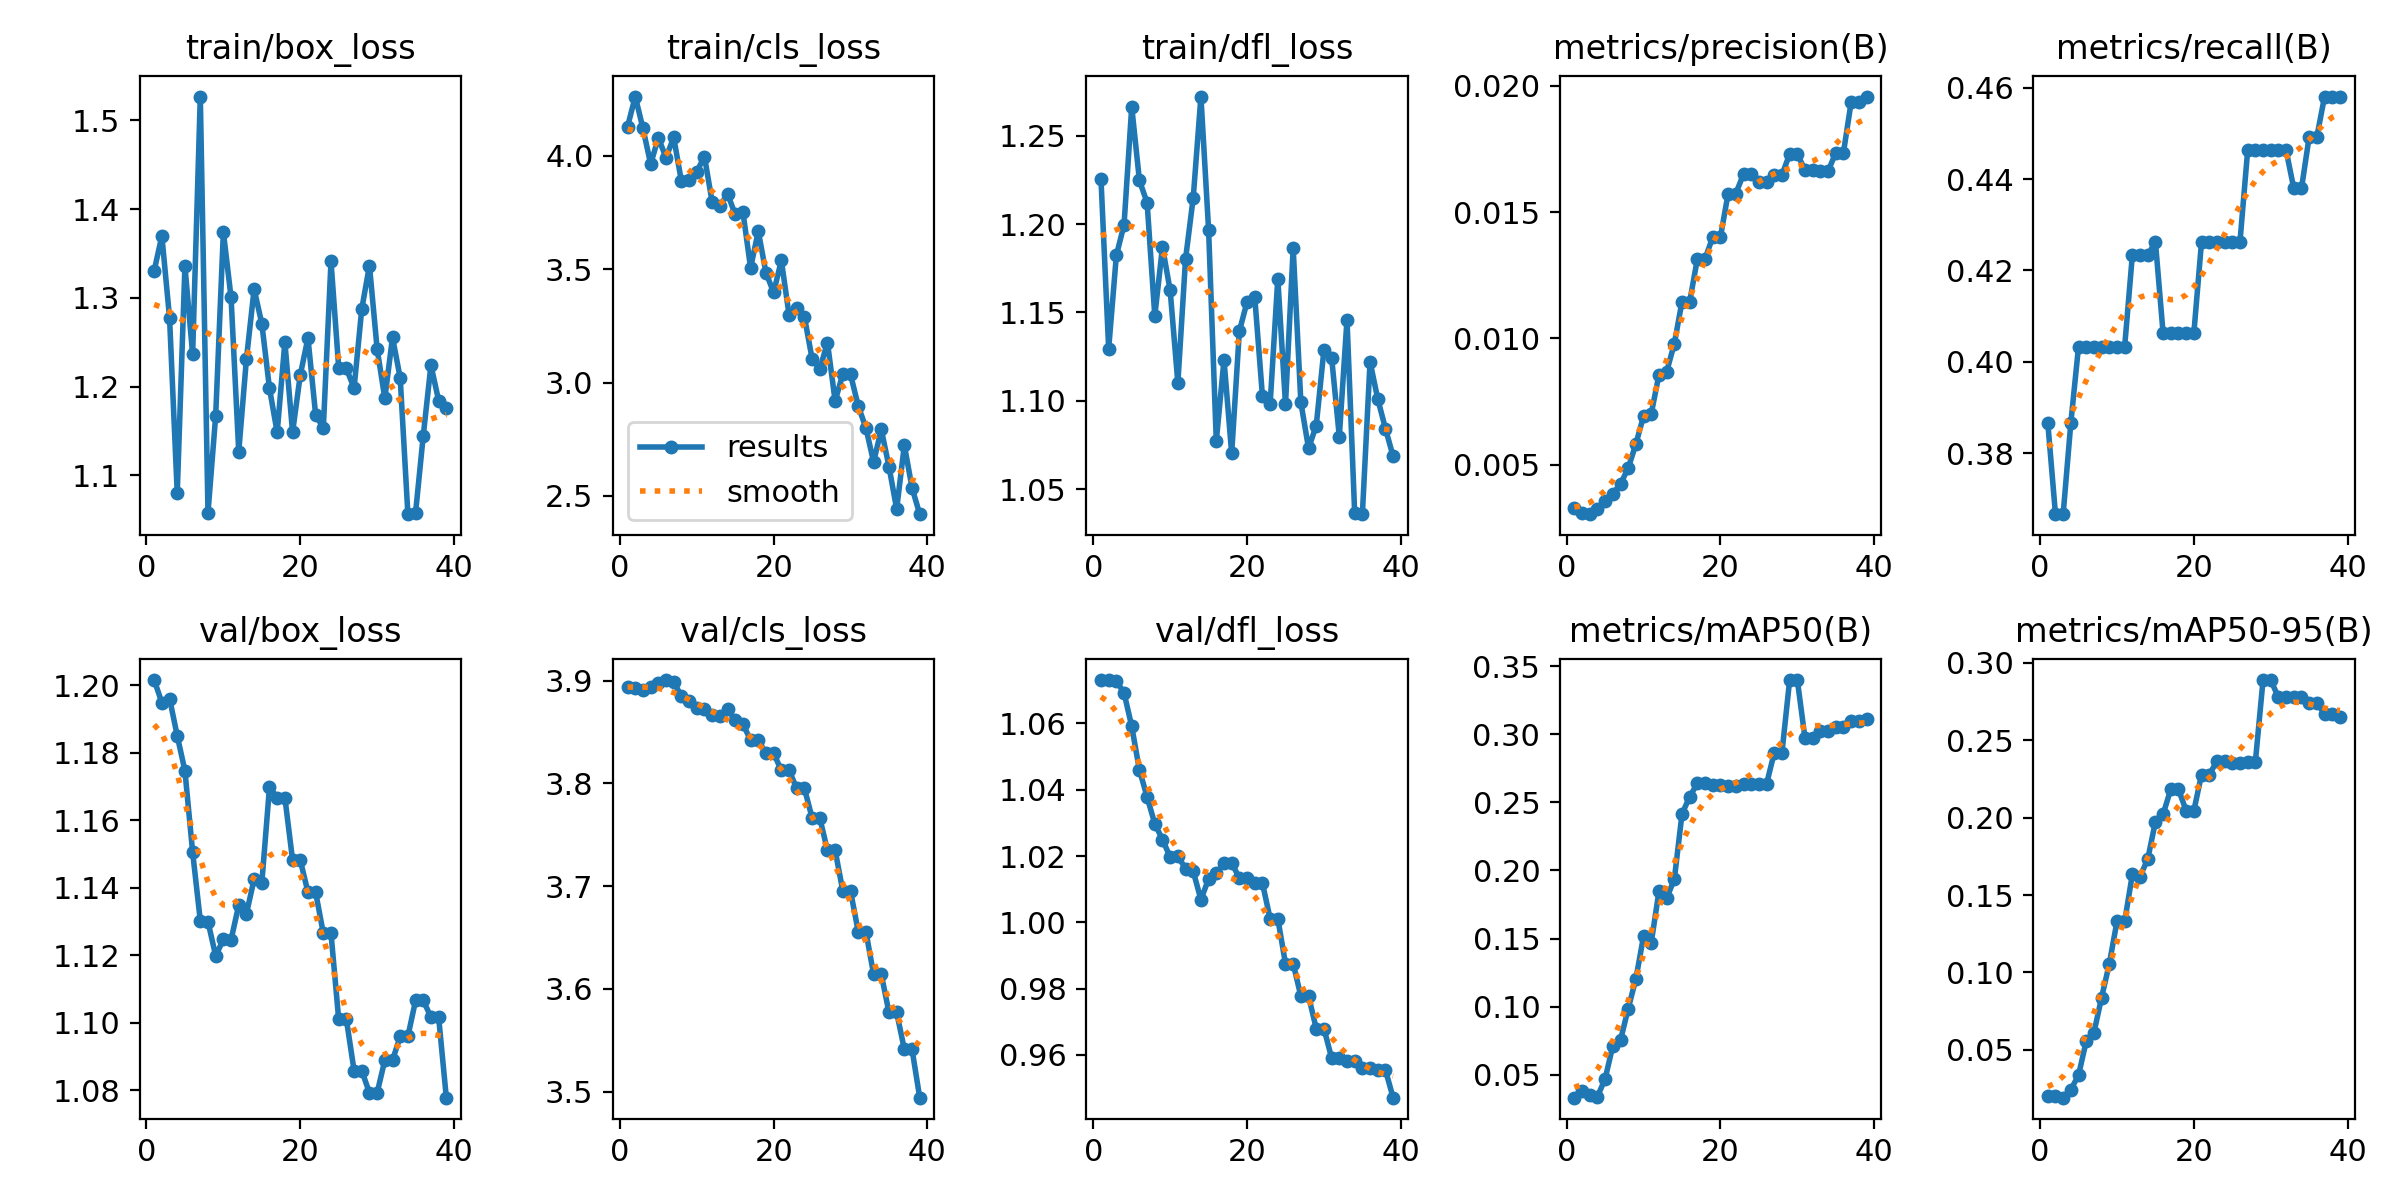

In [ ]:
Image("/content/runs/detect/train/results.png")

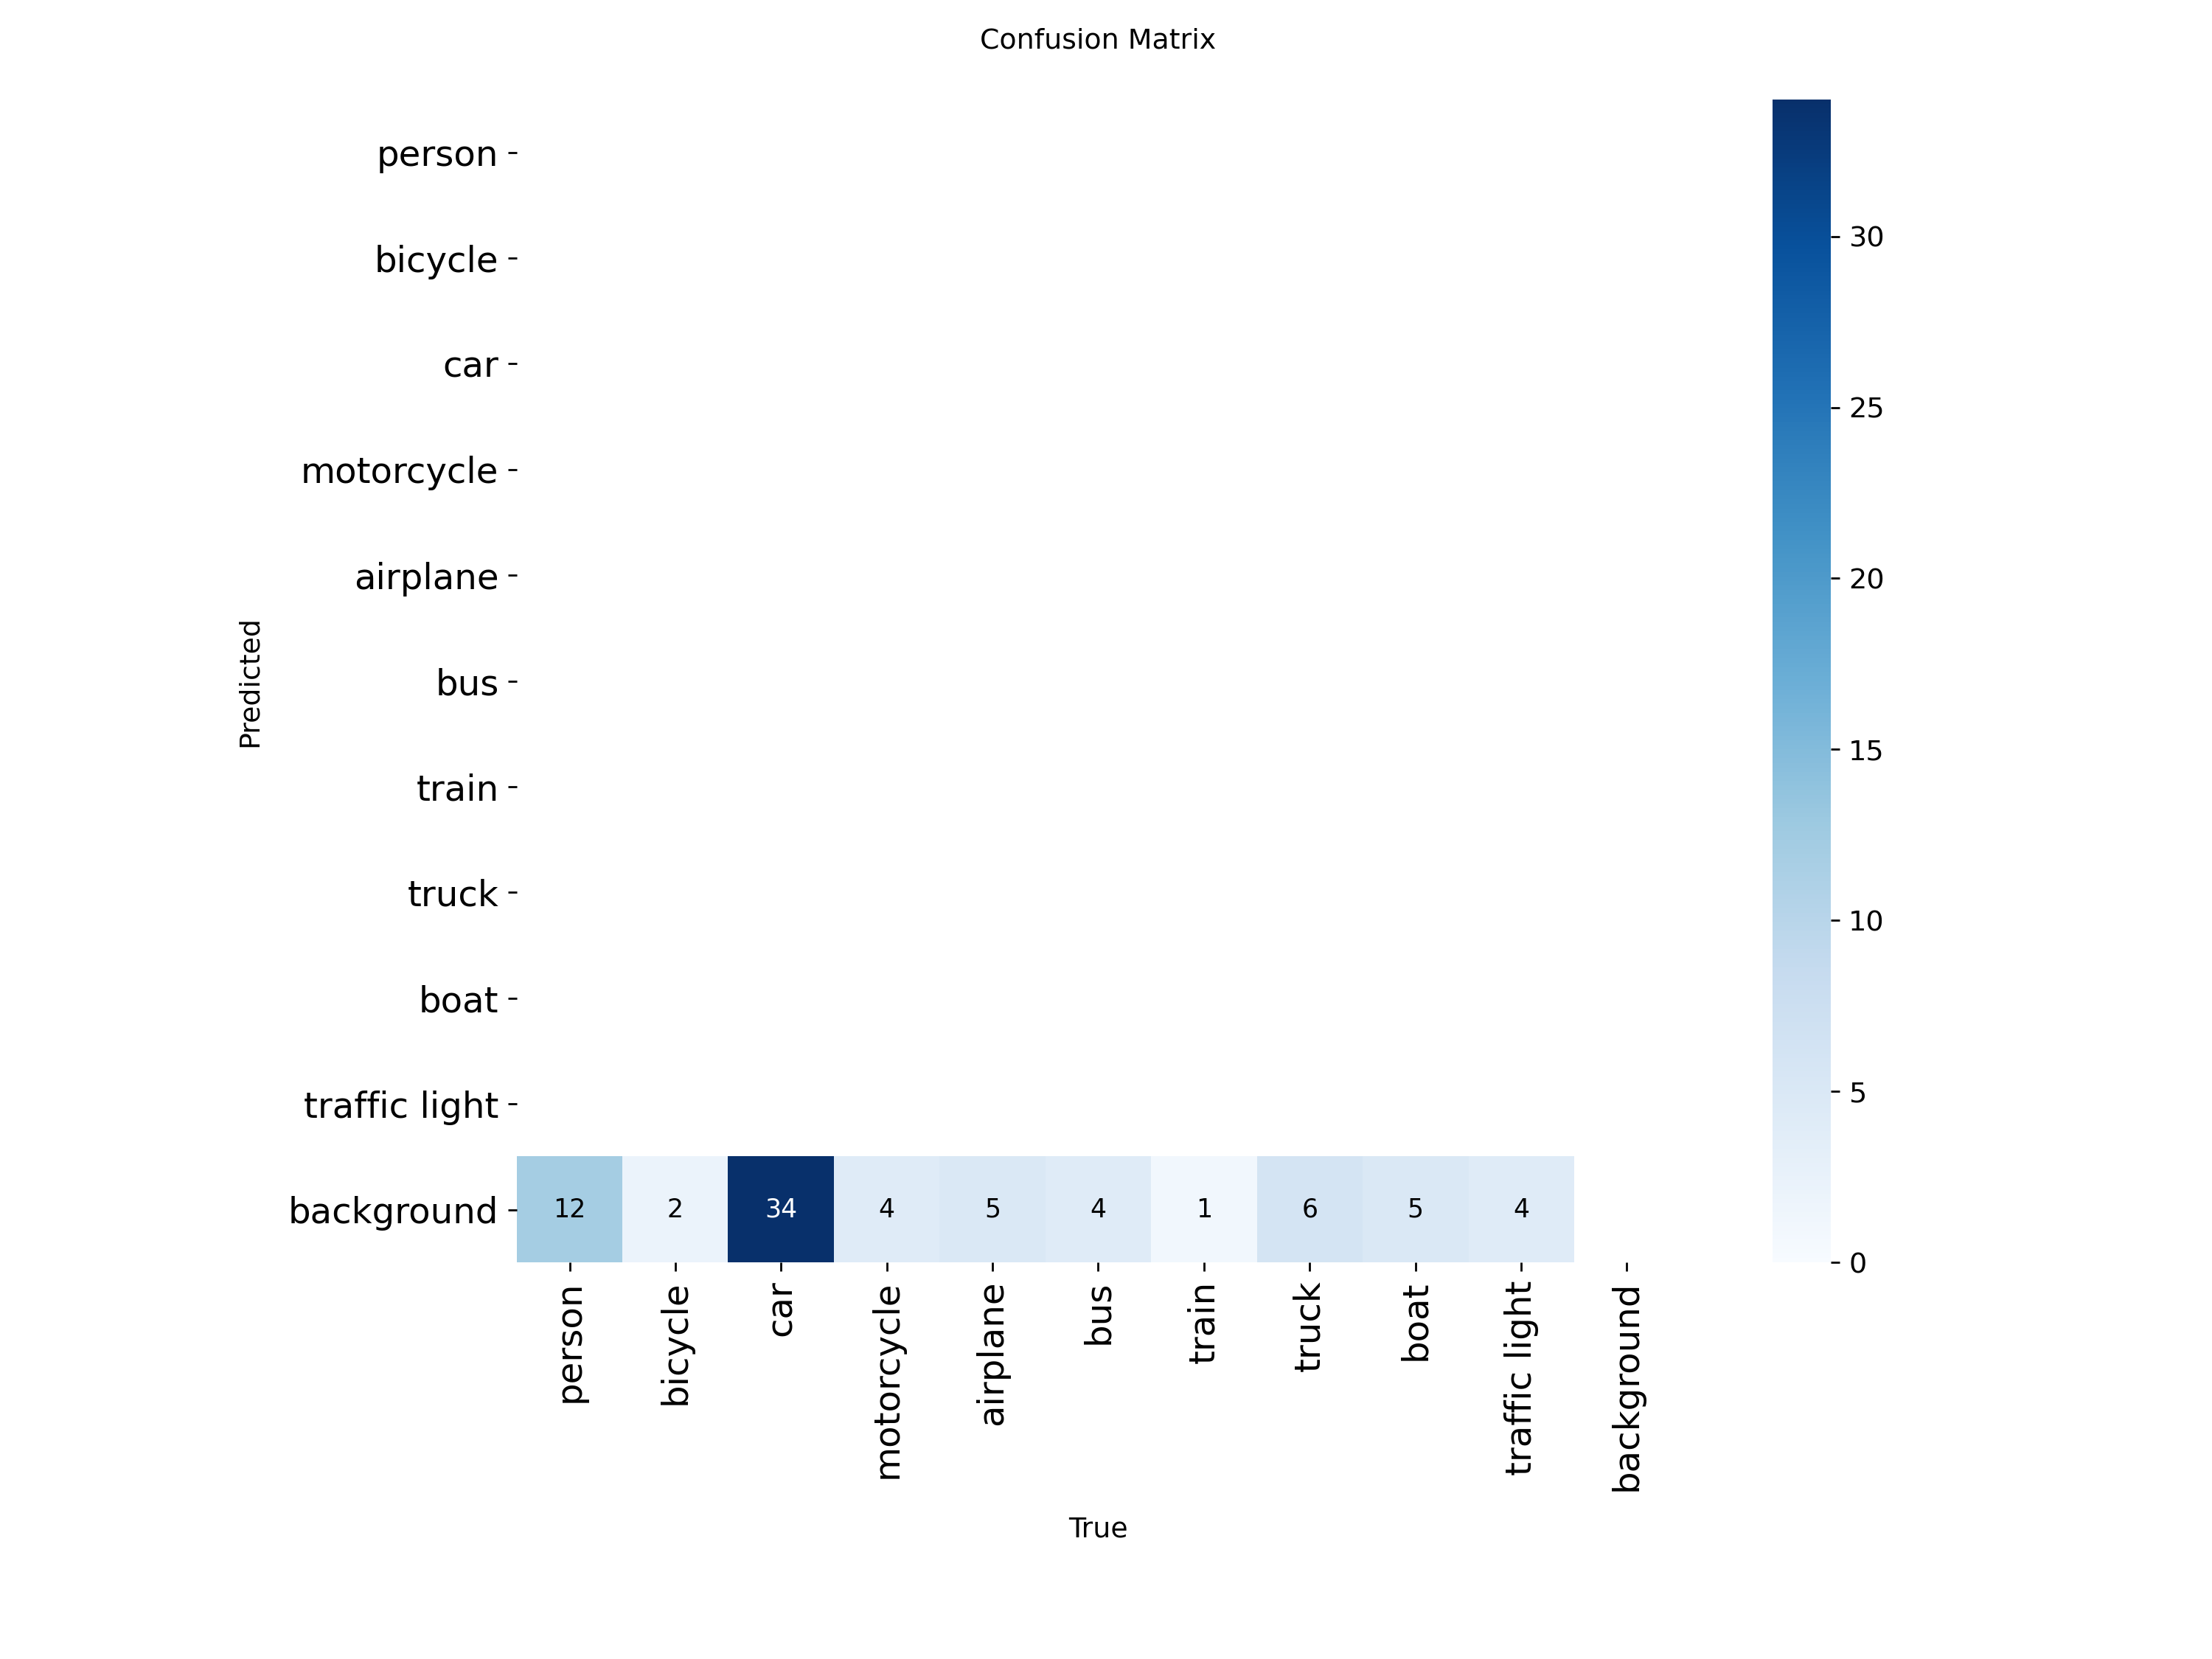

In [ ]:
Image("/content/runs/detect/train/confusion_matrix.png")

In [ ]:
from ultralytics import YOLO

best_model = YOLO("/content/runs/detect/train/weights/best.pt")

In [ ]:
best_model.predict(
    source="/content/coco128/images/train2017",
    conf=0.01,
    save=True
)


image 1/128 /content/coco128/images/train2017/000000000009.jpg: 480x640 (no detections), 10.7ms
image 2/128 /content/coco128/images/train2017/000000000025.jpg: 448x640 (no detections), 6.5ms
image 3/128 /content/coco128/images/train2017/000000000030.jpg: 448x640 (no detections), 7.1ms
image 4/128 /content/coco128/images/train2017/000000000034.jpg: 448x640 (no detections), 5.8ms
image 5/128 /content/coco128/images/train2017/000000000036.jpg: 640x512 (no detections), 6.4ms
image 6/128 /content/coco128/images/train2017/000000000042.jpg: 480x640 (no detections), 6.5ms
image 7/128 /content/coco128/images/train2017/000000000049.jpg: 640x512 (no detections), 6.5ms
image 8/128 /content/coco128/images/train2017/000000000061.jpg: 512x640 (no detections), 6.5ms
image 9/128 /content/coco128/images/train2017/000000000064.jpg: 640x480 (no detections), 6.4ms
image 10/128 /content/coco128/images/train2017/000000000071.jpg: 448x640 (no detections), 6.6ms
image 11/128 /content/coco128/images/train2017/

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light'}
 obb: None
 orig_img: array([[[115,  21,   2],
         [115,  21,   2],
         [115,  21,   2],
         ...,
         [191, 171, 136],
         [188, 170, 133],
         [187, 169, 132]],
 
        [[115,  21,   2],
         [115,  21,   2],
         [115,  21,   2],
         ...,
         [193, 171, 135],
         [192, 170, 134],
         [189, 170, 133]],
 
        [[115,  21,   2],
         [115,  21,   2],
         [115,  22,   1],
         ...,
         [198, 172, 136],
         [197, 171, 135],
         [196, 170, 133]],
 
        ...,
 
        [[  7,   0,   7],
         [  7,   0,   7],
         [  6,   2,   8],
         ...,
         [ 35,   8,   4],
         [ 30,   2,   2],
         [ 33,   7

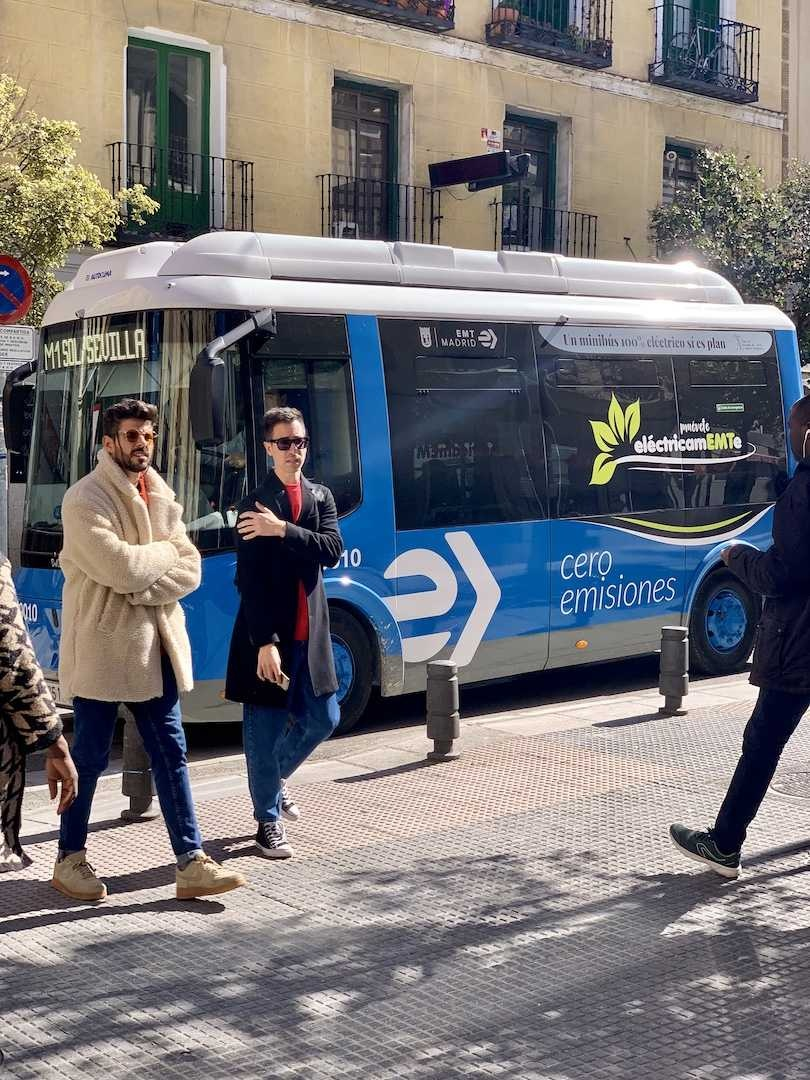

In [ ]:
from IPython.display import Image
Image("/content/runs/detect/predict/bus.jpg")

In [ ]:
model = YOLO("yolov8n.pt")

model.predict(
    "https://ultralytics.com/images/bus.jpg",
    save=True
)


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 15.1ms
Speed: 2.1ms preprocess, 15.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict3


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

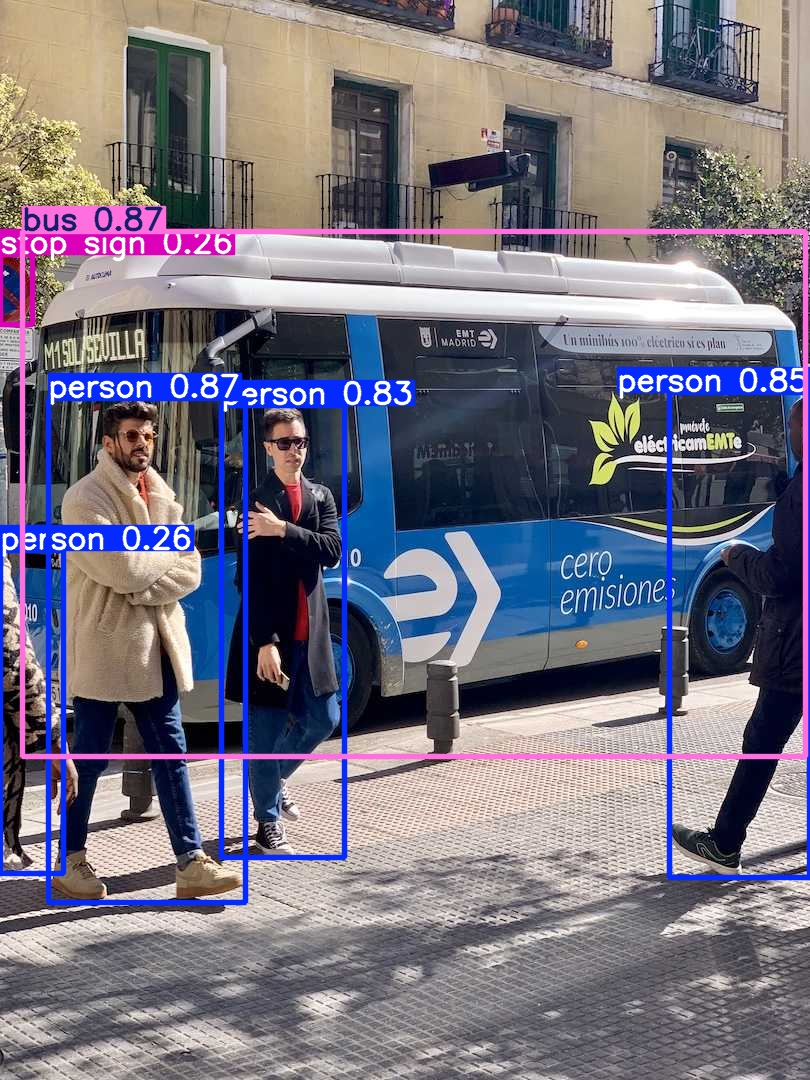

In [ ]:
from IPython.display import Image
Image("/content/runs/detect/predict3/bus.jpg")

In [ ]:
shutil.make_archive("training_results", 'zip', "/content/runs/detect/train")

'/content/training_results.zip'

In [ ]:
shutil.make_archive("prediction_results", 'zip', "/content/runs/detect/predict")

'/content/prediction_results.zip'

In [ ]:
from google.colab import files

files.download("training_results.zip")
files.download("prediction_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>